In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

In [2]:
sb_path = Path('/g/data/er8/users/cd3022/Irradiance-comparisons/weather-features/sea_breeze')

him_files = [f for f in sb_path.glob('himawari*.nc')]
ds_him = xr.open_mfdataset(him_files, combine='nested', concat_dim='date')

bar_files = [f for f in sb_path.glob('barra-r2*.nc')]
ds_br2 = xr.open_mfdataset(bar_files, combine='nested', concat_dim='date')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/jobfs/160357924.gadi-pbs/ipykernel_138539/3136311425.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_him = xr.open_mfdataset(him_files, combine='nested', concat_dim='date')
/jobfs/160357924.gadi-pbs/ipykernel_138539/3136311425.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to

In [3]:
freq_list = []
total = 0
freq_files = [f for f in sb_path.glob('*TOTAL_FREQ_*')]
for file in freq_files:
    ds = xr.open_dataset(file)
    total += ds.freq.item()
    freq_list.append(ds)
sb_freq = xr.concat(freq_list,dim='year')

/jobfs/160357924.gadi-pbs/ipykernel_138539/662712056.py:8: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  sb_freq = xr.concat(freq_list,dim='year')


In [4]:
'''
2016 data currently busted, need to fix!!!
'''

sb_freq_fix = sb_freq.where(sb_freq.year != '2016', drop=True)

In [8]:
counts = sb_freq_fix.mask.sum(dim='year')

In [9]:
mean_him = ds_him.annual_mean_ghi.mean(dim='date')
mean_br2 = ds_br2.annual_mean_ghi.mean(dim='date')

mean_him = mean_him.interp(
    lat=mean_br2.lat,
    lon=mean_br2.lon,
    method='linear'
)
counts = counts.interp(
    lat=mean_br2.lat,
    lon=mean_br2.lon,
    method='linear'
)

freq = counts / total

In [10]:
diff = mean_br2 - mean_him
comb = diff * freq

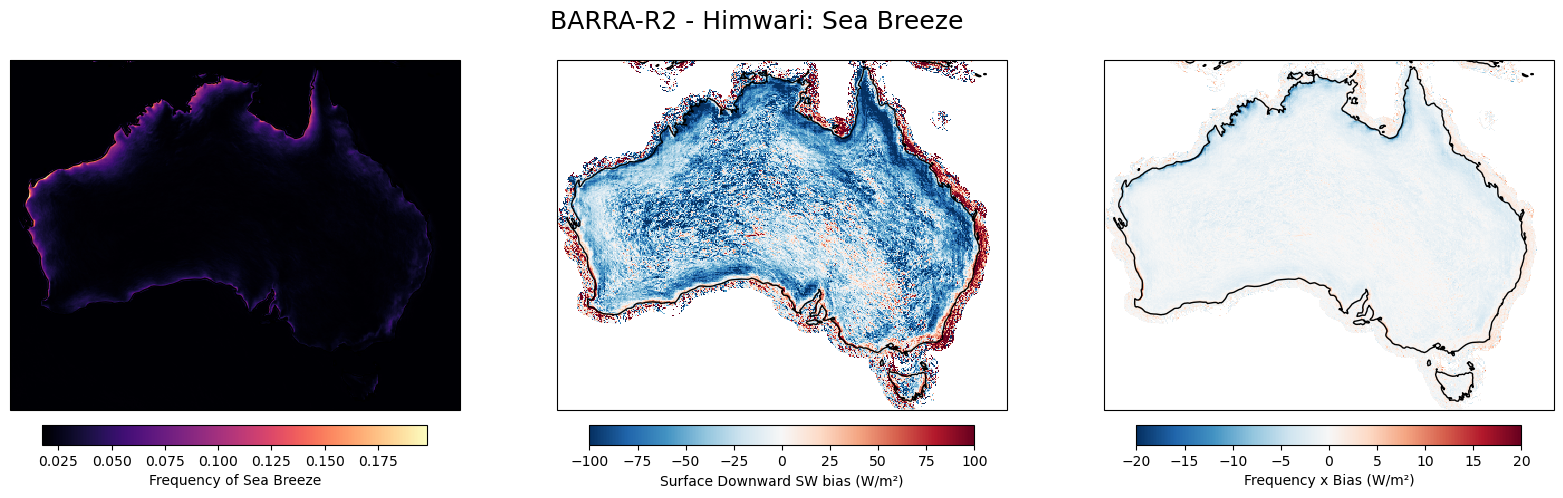

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5), subplot_kw={'projection': ccrs.PlateCarree()})

mesh_freq = ax[0].pcolormesh(
    freq.lon,
    freq.lat,
    freq,
    cmap='magma', shading='auto',
    # vmin=0, vmax=0.3,
    transform=ccrs.PlateCarree()
)
mesh_diff = ax[1].pcolormesh(
    diff.lon,
    diff.lat,
    diff,
    cmap='RdBu_r', shading='auto',
    vmin=-100, vmax=100,
    transform=ccrs.PlateCarree()
)
mesh_comb = ax[2].pcolormesh(
    comb.lon,
    comb.lat,
    comb,
    cmap='RdBu_r', shading='auto',
    vmin=-20, vmax=20,
    transform=ccrs.PlateCarree()
)
ax[0].coastlines()
ax[1].coastlines()
ax[2].coastlines()
fig.suptitle(f'BARRA-R2 - Himwari: Sea Breeze', fontsize=18)

cbar_freq= fig.colorbar(mesh_freq, ax=ax[0], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_freq.set_label(f"Frequency of Sea Breeze")
cbar_diff = fig.colorbar(mesh_diff, ax=ax[1], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_diff.set_label("Surface Downward SW bias (W/m²)")
cbar_comb = fig.colorbar(mesh_comb, ax=ax[2], orientation='horizontal', fraction=0.05, pad=0.04)
cbar_comb.set_label("Frequency x Bias (W/m²)")
plt.savefig('/home/548/cd3022/figures/Irradiance_comparisons/weather-features/sb_br2_bias.png', dpi=500)